imagens usadas disponíveis em: https://drive.google.com/drive/folders/1gwDOKvhtPspWmflDCIzU6NwHS43R3UsZ?usp=sharing

### 1.


In [1]:
!pip install -U gdown -q
!gdown -q --folder "https://drive.google.com/drive/folders/1gwDOKvhtPspWmflDCIzU6NwHS43R3UsZ?usp=sharing" -O /content/imagens/

In [2]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path("/content/imagens")
OUT_DIR = Path("/content/4_results")

TRIOS = {
    "livro":  ["livro1.jpg", "livro2.jpg", "livro3.jpg"],
    "caixa":  ["caixa1.jpg", "caixa2.jpg", "caixa3.jpg"],
    "hp":     ["hp1.jpg", "hp2.jpg", "hp3.jpg"],
    "lambda": ["lambda1.jpg", "lambda2.jpg", "lambda3.jpg"],
    "xero":   ["xero1.jpg", "xero2.jpg", "xero3.jpg"],
}

def carrega(caminho, max_lado=1100):
    img = cv2.imread(str(caminho))

    if img is None:
        raise FileNotFoundError(f"nao foi possivel ler imagem em {caminho}")

    h, w = img.shape[:2]
    escala = min(1.0, max_lado / max(h, w))

    if escala < 1.0:
        img = cv2.resize(
            img,
            (int(w * escala), int(h * escala)),
            interpolation=cv2.INTER_AREA
        )
    return img

def pega_siftmatches(img1, img2, ratio=0.75):
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    sift = cv2.SIFT_create(nfeatures=5000)

    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    if des1 is None or des2 is None:
        return kp1, kp2, []

    bf = cv2.BFMatcher(cv2.NORM_L2)
    pares = bf.knnMatch(des1, des2, k=2)

    bons_matches = []

    for par in pares:
        if len(par) != 2:
            continue
        m, n = par
        if m.distance < ratio * n.distance:
            bons_matches.append(m)

    return kp1, kp2, bons_matches

def calculahomografia(img_origem, img_destino):
    melhor_resultado = None

    for ratio in [0.75, 0.80, 0.85, 0.90]:
        kp1, kp2, matches = pega_siftmatches(img_origem, img_destino, ratio)

        if len(matches) < 4:
            continue

        pts_origem = np.float32(
            [kp1[m.queryIdx].pt for m in matches]
        ).reshape(-1, 1, 2)

        pts_destino = np.float32(
            [kp2[m.trainIdx].pt for m in matches]
        ).reshape(-1, 1, 2)

        H, mascara = cv2.findHomography(
            pts_origem,
            pts_destino,
            cv2.RANSAC,
            5.0
        )

        if H is None:
            continue

        inliers = int(mascara.sum()) if mascara is not None else 0

        if melhor_resultado is None or inliers > melhor_resultado["inliers"]:
            melhor_resultado = {
                "H": H,
                "matches": len(matches),
                "inliers": inliers,
                "ratio": ratio,
            }

        if inliers >= 8:
            break

    return melhor_resultado

def calculacanvas(imagens, transformacoes):
    todos_cantos = []

    for img, H in zip(imagens, transformacoes):
        h, w = img.shape[:2]

        cantos = np.float32([
            [0, 0],
            [w, 0],
            [w, h],
            [0, h]
        ]).reshape(-1, 1, 2)

        cantos_transformados = cv2.perspectiveTransform(cantos, H)
        todos_cantos.append(cantos_transformados)

    todos_cantos = np.concatenate(todos_cantos, axis=0)

    xmin, ymin = np.floor(todos_cantos.min(axis=0).ravel()).astype(int)
    xmax, ymax = np.ceil(todos_cantos.max(axis=0).ravel()).astype(int)

    largura = xmax - xmin
    altura = ymax - ymin

    translacao = np.array([
        [1, 0, -xmin],
        [0, 1, -ymin],
        [0, 0, 1]
    ], dtype=np.float64)

    return translacao, largura, altura

def mescla_imagens(imagens, transformacoes, largura, altura):
    acumulado = np.zeros((altura, largura, 3), dtype=np.float32)
    pesos = np.zeros((altura, largura, 1), dtype=np.float32)

    for img, H in zip(imagens, transformacoes):
        warp = cv2.warpPerspective(img, H, (largura, altura))

        mascara = np.ones(img.shape[:2], dtype=np.uint8) * 255
        mascara_warp = cv2.warpPerspective(mascara, H, (largura, altura))
        mascara_warp = (mascara_warp > 0).astype(np.float32)[..., None]

        acumulado += warp.astype(np.float32) * mascara_warp
        pesos += mascara_warp

    panorama = acumulado / np.maximum(pesos, 1.0)
    panorama = np.clip(panorama, 0, 255).astype(np.uint8)

    mascara_final = (pesos[..., 0] > 0).astype(np.uint8)
    coords = cv2.findNonZero(mascara_final)

    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        panorama = panorama[y:y + h, x:x + w]

    return panorama

def transformacoesPplano(H01, H12, plano):
    I = np.eye(3, dtype=np.float64)
    H10 = np.linalg.inv(H01)
    H21 = np.linalg.inv(H12)

    if plano == 1:
        return [I, H10, H10 @ H21]
    if plano == 2:
        return [H01, I, H21]
    if plano == 3:
        return [H12 @ H01, H12, I]

    raise ValueError("o plalano deve ser 1, 2 ou 3")

def gera_panoramas(nome_trio, arquivos):
    imagens = []

    for arquivo in arquivos:
        caminhos_encontrados = list(BASE_DIR.rglob(arquivo))
        if not caminhos_encontrados:
             raise FileNotFoundError(f"O arquivo {arquivo} não foi encontrado no download!")
        imagens.append(carrega(caminhos_encontrados[0]))

    resultado_01 = calculahomografia(imagens[0], imagens[1])
    resultado_12 = calculahomografia(imagens[1], imagens[2])

    H01 = resultado_01["H"]
    H12 = resultado_12["H"]

    print(f"\n[{nome_trio.upper()}] processando")

    panoramas_gerados = []

    for plano in [1, 2, 3]:
        transformacoes = transformacoesPplano(H01, H12, plano)

        img_base = imagens[plano - 1]
        altura, largura = img_base.shape[:2]
        translacao = np.eye(3, dtype=np.float64)

        transformacoes_canvas = [translacao @ H for H in transformacoes]

        panorama = mescla_imagens(imagens, transformacoes_canvas, largura, altura)
        panoramas_gerados.append(panorama)

        saida = OUT_DIR / f"{nome_trio}_plano_imagem_{plano}.png"
        cv2.imwrite(str(saida), panorama)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.patch.set_facecolor('white')
    fig.suptitle(f"trio: {nome_trio.upper()}", fontsize=18, fontweight='bold')

    titulos_originais = ["imagem 1", "imagem 2", "imagem 3"]
    titulos_panoramas = ["plano 1", "plano 2", "plano 3"]

    # linha 0 - imagens originais
    for i in range(3):
        ax = axes[0, i]
        img_rgb = cv2.cvtColor(imagens[i], cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(titulos_originais[i], fontsize=12)
        ax.axis('off')

    # linha 1- resultados panoramas
    for i in range(3):
        ax = axes[1, i]
        pano_rgb = cv2.cvtColor(panoramas_gerados[i], cv2.COLOR_BGR2RGB)
        ax.imshow(pano_rgb)
        ax.set_title(titulos_panoramas[i], fontsize=12)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    print("-" * 60)

def main():
    OUT_DIR.mkdir(exist_ok=True)

    print("processamento iniciado")

    for nome_trio, arquivos in TRIOS.items():
        try:
            gera_panoramas(nome_trio, arquivos)
        except Exception as e:
            print(f"erro ao processar trio {nome_trio}: {e}")

    print(f"imagens salvas em {OUT_DIR}")

if __name__ == "__main__":
    main()

Output hidden; open in https://colab.research.google.com to view.

### 2.


tamanho da imagem: 7175x4334 pixels

total de blobs detectados: 20

 coordenadas canto inferior esquerdo (metros) = 0,0) 
  jogador 1: pixel_orig=(3698,1347)  →  X = 84.24 m,  Y = 63.86 m  (área=939 px²)
  jogador 2: pixel_orig=(3915,1268)  →  X = 93.95 m,  Y = 65.98 m  (área=414 px²)


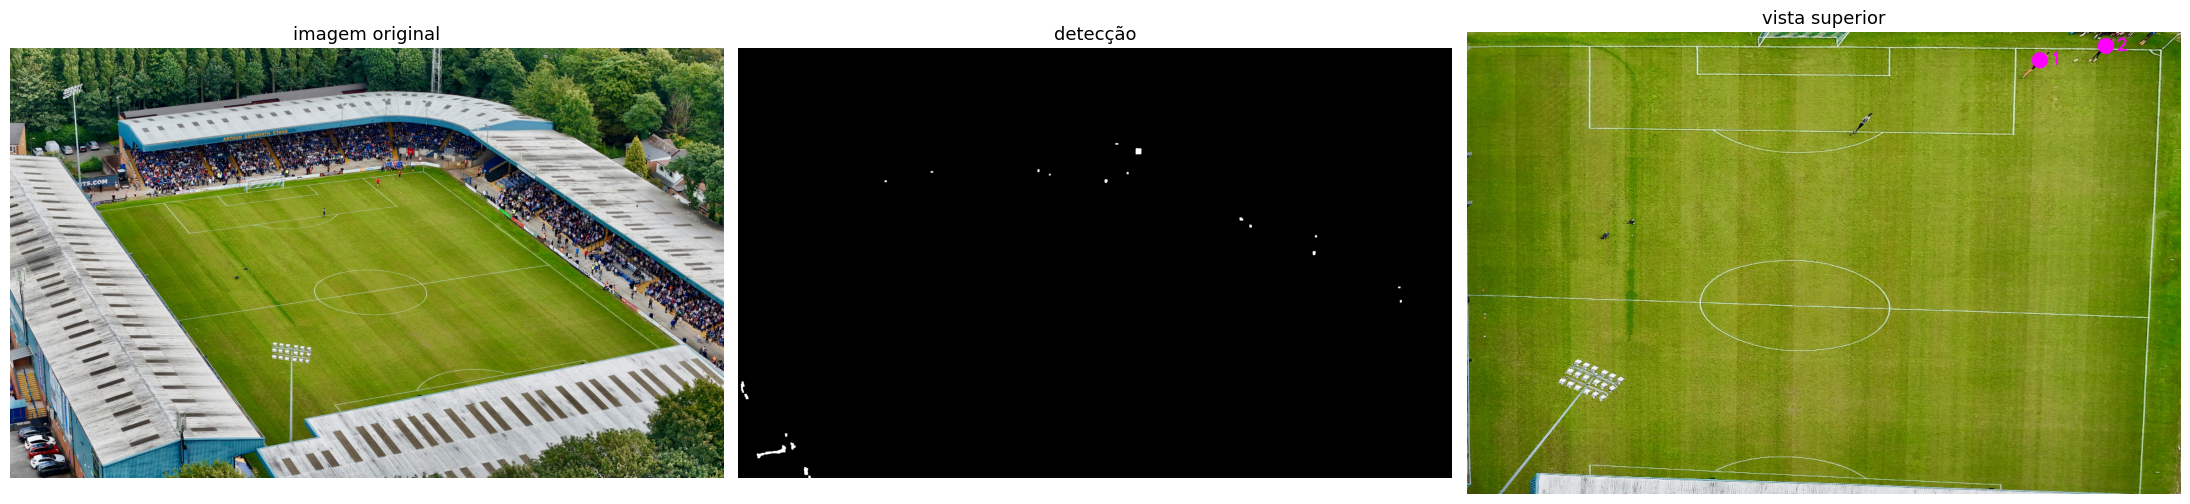


imagem salva


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('soccer.jpg')
print(f"tamanho da imagem: {img.shape[1]}x{img.shape[0]} pixels")
pts_src = np.array([
    [862,  1600],
    [2592, 4010],
    [4162, 1190],
    [6727, 2985]
], dtype=float)

escala = 10
largura_img = int(105*escala)
altura_img  = int(68*escala)

pts_dst_img = np.array([
    [0,0],
    [0,altura_img ],
    [largura_img, 0],
    [largura_img, altura_img]
], dtype=float)

pts_dst_metros = np.array([
    [0,68],
    [0,0],
    [105,68],
    [105,0]
], dtype=float)

Himg,    _ = cv2.findHomography(pts_src, pts_dst_img)
Hmetros, _ = cv2.findHomography(pts_src, pts_dst_metros)
img_out = cv2.warpPerspective(img, Himg, (largura_img, altura_img))
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

mask1 = cv2.inRange(hsv, np.array([0,   120, 70]), np.array([10,  255, 255]))
mask2 = cv2.inRange(hsv, np.array([160, 120, 70]), np.array([180, 255, 255]))
mask_red = cv2.bitwise_or(mask1, mask2)

kernel = np.ones((9, 9), np.uint8)
mask_red = cv2.morphologyEx(mask_red, cv2.MORPH_OPEN,  kernel, iterations=2)
mask_red = cv2.morphologyEx(mask_red, cv2.MORPH_CLOSE, kernel, iterations=2)

contours, _ = cv2.findContours(mask_red, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#(min_area / max_area)
min_area = 300
max_area = 80_000

jogadores = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    if min_area < area < max_area:
        M = cv2.moments(cnt)
        if M['m00'] != 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
            jogadores.append((cx, cy, area))

# ordena do: maior blob para menor
jogadores.sort(key=lambda x: x[2], reverse=True)
print(f"\ntotal de blobs detectados: {len(jogadores)}")

def projetar_ponto(H, ponto_pixel):
    p = np.array([ponto_pixel[0], ponto_pixel[1], 1.0])
    p_t = H @ p
    return p_t[0] / p_t[2], p_t[1] / p_t[2]

# desenhamento de blobss
cores_bgr = [
    (255,   0, 255),
]

print("\n coordenadas canto inferior esquerdo (metros) = 0,0) ")
validos = 0
for i, (cx, cy, area) in enumerate(jogadores):
    x_img, y_img = projetar_ponto(Himg,    (cx, cy))
    x_m,   y_m   = projetar_ponto(Hmetros, (cx, cy))

    # if -> ponto cair dentro do campo projetado
    # aí desenha
    if 0 <= x_img <= largura_img and 0 <= y_img <= altura_img:
        cor = cores_bgr[validos % len(cores_bgr)]
        cv2.circle(img_out, (int(x_img), int(y_img)), 12, cor, -1)
        cv2.putText(img_out, str(validos + 1),
                    (int(x_img) + 16, int(y_img) + 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, cor, 2)
        print(f"  jogador {validos+1}: pixel_orig=({cx},{cy})  →  "
              f"X = {x_m:.2f} m,  Y = {y_m:.2f} m  (área={area:.0f} px²)")
        validos += 1

img_rgb_orig = cv2.cvtColor(img,     cv2.COLOR_BGR2RGB)
img_rgb_out  = cv2.cvtColor(img_out, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

axes[0].imshow(img_rgb_orig)
axes[0].set_title('imagem original', fontsize=13)
axes[0].axis('off')

axes[1].imshow(mask_red, cmap='gray')
axes[1].set_title('detecção', fontsize=13)
axes[1].axis('off')

axes[2].imshow(img_rgb_out)
axes[2].set_title('vista superior', fontsize=13)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('resultado_homografia.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nimagem salva")

### 3.

detectção de cantos
xadrez1.jpg – cantos encontrados
xadrez2.jpg – cantos encontrados
xadrez3.jpg – cantos encontrados
xadrez4.jpg – cantos encontrados

4 de 4 imagens válidas para calibrar
erro de reprojeção: 3.2718 px

matriz intrínseca (K):
[[1.71190987e+03 0.00000000e+00 7.43890538e+02]
 [0.00000000e+00 1.68071134e+03 1.14980816e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

coeficientes de distorção:
  [-0.08114613  0.86911745  0.00716176 -0.01426546 -2.41275508]

focal length: fx=1711.9 px, fy=1680.7 px
centro óptico: cx=743.9 px, cy=1149.8 px
erros de reprojeção por imagem:
  xadrez1.jpg: 0.4868 px
  xadrez2.jpg: 0.5503 px
  xadrez3.jpg: 0.4313 px
  xadrez4.jpg: 0.3848 px
  erro médio: 0.4633 px
projeção do ciruclo virtua:
  centro 3-D : (38.4, 38.4, 0) cm
  raio       : 12.8 cm
-------------------------------------------------------


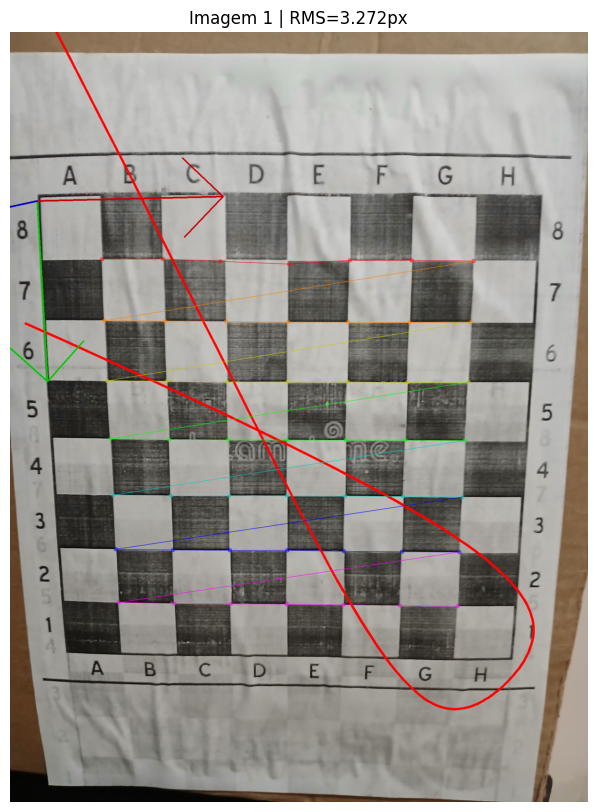

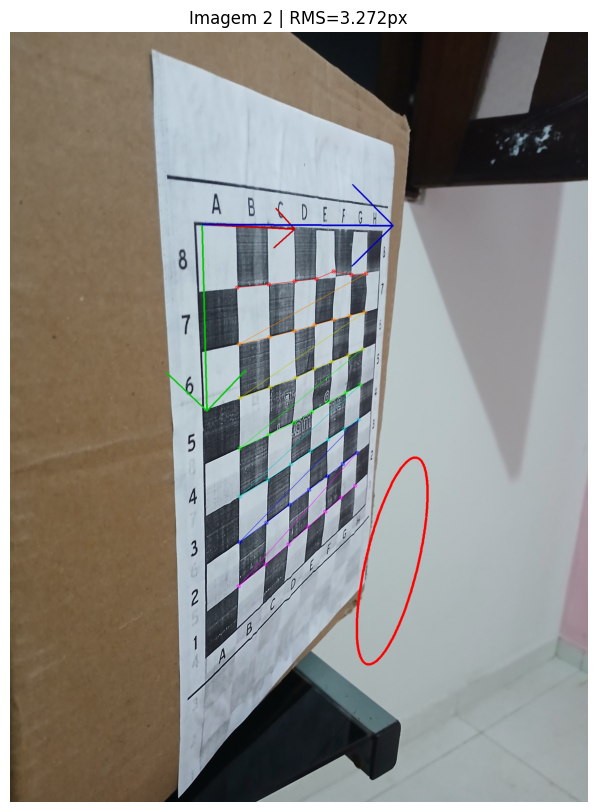

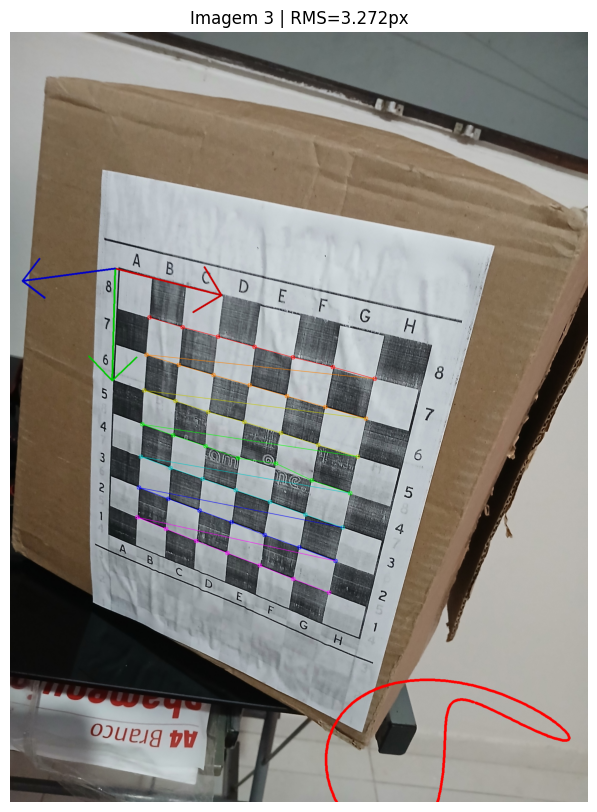

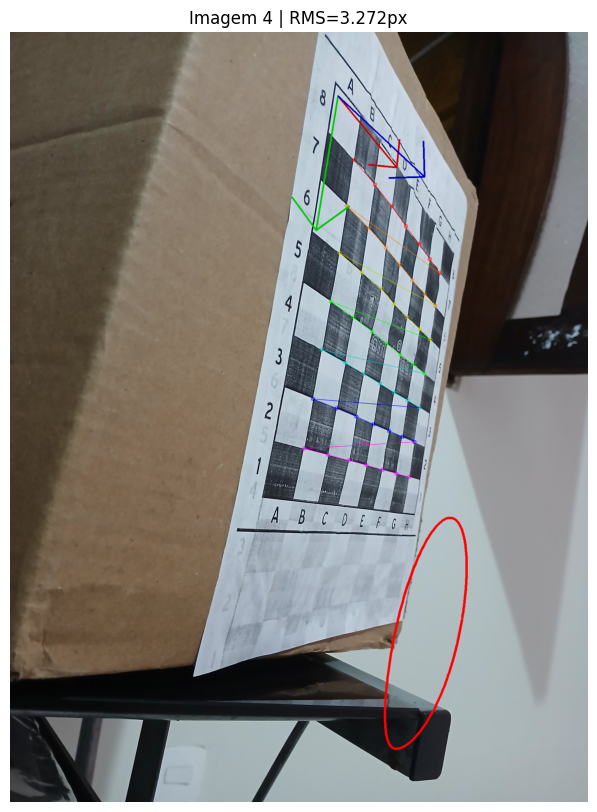


parametros salvos em calibracao_camera.npz


In [ ]:
import numpy as np
import cv2 as cv
import os
import matplotlib.pyplot as plt

SQUARE_SIZE = 3.2 # cm – lado de cada quadrado
INNER_W     = 7 # cantos internos na direção x
INNER_H     = 7 # cantos internos em y
BOARD_COLS  = 8 # colunas de quadrados
BOARD_ROWS  = 8 # linhas de quadrados

# dimensões  totais do tabuleiro
W = BOARD_COLS * SQUARE_SIZE # 25.6 cm
H = BOARD_ROWS * SQUARE_SIZE # também

criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001)

objp = np.zeros((INNER_H * INNER_W, 3), np.float32)
for row in range(INNER_H):
    for col in range(INNER_W):
        idx = row * INNER_W + col
        objp[idx, 0] = (col + 1) * SQUARE_SIZE
        objp[idx, 1] = (row + 1) * SQUARE_SIZE
        # z = 0

IMG_DIR = './'
OUT_DIR = './outputs/'
os.makedirs(OUT_DIR, exist_ok=True)
image_files = ['xadrez1.jpg', 'xadrez2.jpg', 'xadrez3.jpg', 'xadrez4.jpg']

def detect_corners(path):
    img  = cv.imread(path)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    h, w = gray.shape

    for scale in [4, 3]:
        small    = cv.resize(gray, (w // scale, h // scale))
        filtered = cv.bilateralFilter(small, 9, 75, 75)

        for g in [small, filtered]:
            ret, corners = cv.findChessboardCorners(
                g, (INNER_W, INNER_H), cv.CALIB_CB_ADAPTIVE_THRESH
            )
            if ret:
                corners_full = corners * scale
                corners_refined = cv.cornerSubPix(
                    gray, corners_full, (11, 11), (-1, -1), criteria
                )
                return img, corners_refined

    return img, None

# cooleta dados p; calibração
objpoints  = []
imgpoints  = []
valid_imgs = []
valid_names = []
img_size   = None

print("detectção de cantos")

for fname in image_files:
    path = os.path.join(IMG_DIR, fname)
    img, corners = detect_corners(path)

    h, w = img.shape[:2]
    img_size = (w, h)

    if corners is not None:
        objpoints.append(objp.copy())
        imgpoints.append(corners)
        valid_imgs.append(img.copy())
        valid_names.append(fname)
        print(f"{fname} – cantos encontrados")
    else:
        print(f"{fname} – cantos não encontrados")

print(f"\n{len(objpoints)} de {len(image_files)} imagens válidas para calibrar")

rms, mtx, dist, rvecs, tvecs = cv.calibrateCamera(
    objpoints, imgpoints, img_size, None, None
)

print(f"erro de reprojeção: {rms:.4f} px")
print(f"\nmatriz intrínseca (K):\n{mtx}")
print(f"\ncoeficientes de distorção:\n  {dist.ravel()}")
print(f"\nfocal length: fx={mtx[0,0]:.1f} px, fy={mtx[1,1]:.1f} px")
print(f"centro óptico: cx={mtx[0,2]:.1f} px, cy={mtx[1,2]:.1f} px")

print("erros de reprojeção por imagem:")
mean_error = 0.0
for i in range(len(objpoints)):
    imgpoints2, _ = cv.projectPoints(
        objpoints[i], rvecs[i], tvecs[i], mtx, dist
    )
    error = cv.norm(imgpoints[i], imgpoints2, cv.NORM_L2) / len(imgpoints2)
    mean_error += error
    print(f"  {valid_names[i]}: {error:.4f} px")
print(f"  erro médio: {mean_error / len(objpoints):.4f} px")

# centro em (1.5W, 1.5H, 0),  raio r = 0.5W
# p(θ) = (r·cos(θ) + 1.5W,  r·sin(θ) + 1.5H,  0)

r_circ = 0.5 * W # 12.8 cm
cx_3d  = 1.5 * W # 38.4 cm
cy_3d  = 1.5 * H # 38.4 cm
N_pts  = 360 # pontos amostrados 💀

theta     = np.linspace(0, 2 * np.pi, N_pts, endpoint=False)
circle_3d = np.column_stack([
    r_circ * np.cos(theta) + cx_3d,
    r_circ * np.sin(theta) + cy_3d,
    np.zeros(N_pts)
]).astype(np.float32)

print("projeção do ciruclo virtua:")
print(f"  centro 3-D : ({cx_3d:.1f}, {cy_3d:.1f}, 0) cm")
print(f"  raio       : {r_circ:.1f} cm")
print("-" * 55)

COLOR_CIRCLE  = (0,   0, 255)
COLOR_CORNERS = (0, 255,   0)
THICKNESS     = 6

saved_files = []
for i, (img, rvec, tvec, name) in enumerate(
        zip(valid_imgs, rvecs, tvecs, valid_names)):

    canvas = img.copy()
    ih, iw = canvas.shape[:2]

    # projeta circulo
    pts2d, _ = cv.projectPoints(circle_3d, rvec, tvec, mtx, dist)
    pts2d    = pts2d.reshape(-1, 2).astype(np.float32)

    # constroi o polígono somente com pontos dentro ou pertos da imagem
    MARGIN = 50
    poly = []
    for pt in pts2d:
        x, y = float(pt[0]), float(pt[1])
        if (-MARGIN < x < iw + MARGIN) and (-MARGIN < y < ih + MARGIN):
            poly.append([[int(round(x)), int(round(y))]])

    if len(poly) > 2:
        poly_np = np.array(poly, dtype=np.int32)
        cv.polylines(canvas, [poly_np], isClosed=False,
                     color=COLOR_CIRCLE, thickness=THICKNESS)

    #  marca os cantos detectados
    cv.drawChessboardCorners(canvas, (INNER_W, INNER_H), imgpoints[i], True)

    # ixos de coordenadas do tabuleiro
    axis_pts = np.float32([
        [0, 0, 0],
        [3 * SQUARE_SIZE, 0, 0],   # x - vermelho
        [0, 3 * SQUARE_SIZE, 0],   # y - verde
        [0, 0, -3 * SQUARE_SIZE],  # z - azul (sai do plano)
    ])
    ax2d, _ = cv.projectPoints(axis_pts, rvec, tvec, mtx, dist)
    ax2d    = ax2d.reshape(-1, 2).astype(int)
    origin  = tuple(ax2d[0])
    cv.arrowedLine(canvas, origin, tuple(ax2d[1]), (0, 0, 200), 4, tipLength=0.3)
    cv.arrowedLine(canvas, origin, tuple(ax2d[2]), (0, 200, 0), 4, tipLength=0.3)
    cv.arrowedLine(canvas, origin, tuple(ax2d[3]), (200, 0, 0), 4, tipLength=0.3)

    txt = f"Imagem {i+1} | RMS={rms:.3f}px"

    canvas_rgb = cv.cvtColor(canvas, cv.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.title(txt)
    plt.imshow(canvas_rgb)
    plt.axis('off')
    plt.show()

np.savez(
    os.path.join(OUT_DIR, 'calibracao_camera.npz'),
    camera_matrix   = mtx,
    dist_coeffs     = dist,
    rms_error       = rms,
)
print(f"\nparametros salvos em calibracao_camera.npz")

#### 4.


modo retrato usando mapa de disparidade
pares usados:
  garrafa: garrafa_esq.png + garrafa_dir.png
  livro: livro2.jpg + livro3.jpg
  tapaue: gar2.jpg + gar3.jpg

processando par garrafa
  matches bons: 388 | inliers: 230
grade salva em: 4-results/garrafa_grade_completa.png

processando par livro
  matches bons: 228 | inliers: 190
grade salva em: 4-results/livro_grade_completa.png

processando par tapaue
  matches bons: 28 | inliers: 13
grade salva em: 4-results/tapaue_grade_completa.png
resultados salvos em 4-results


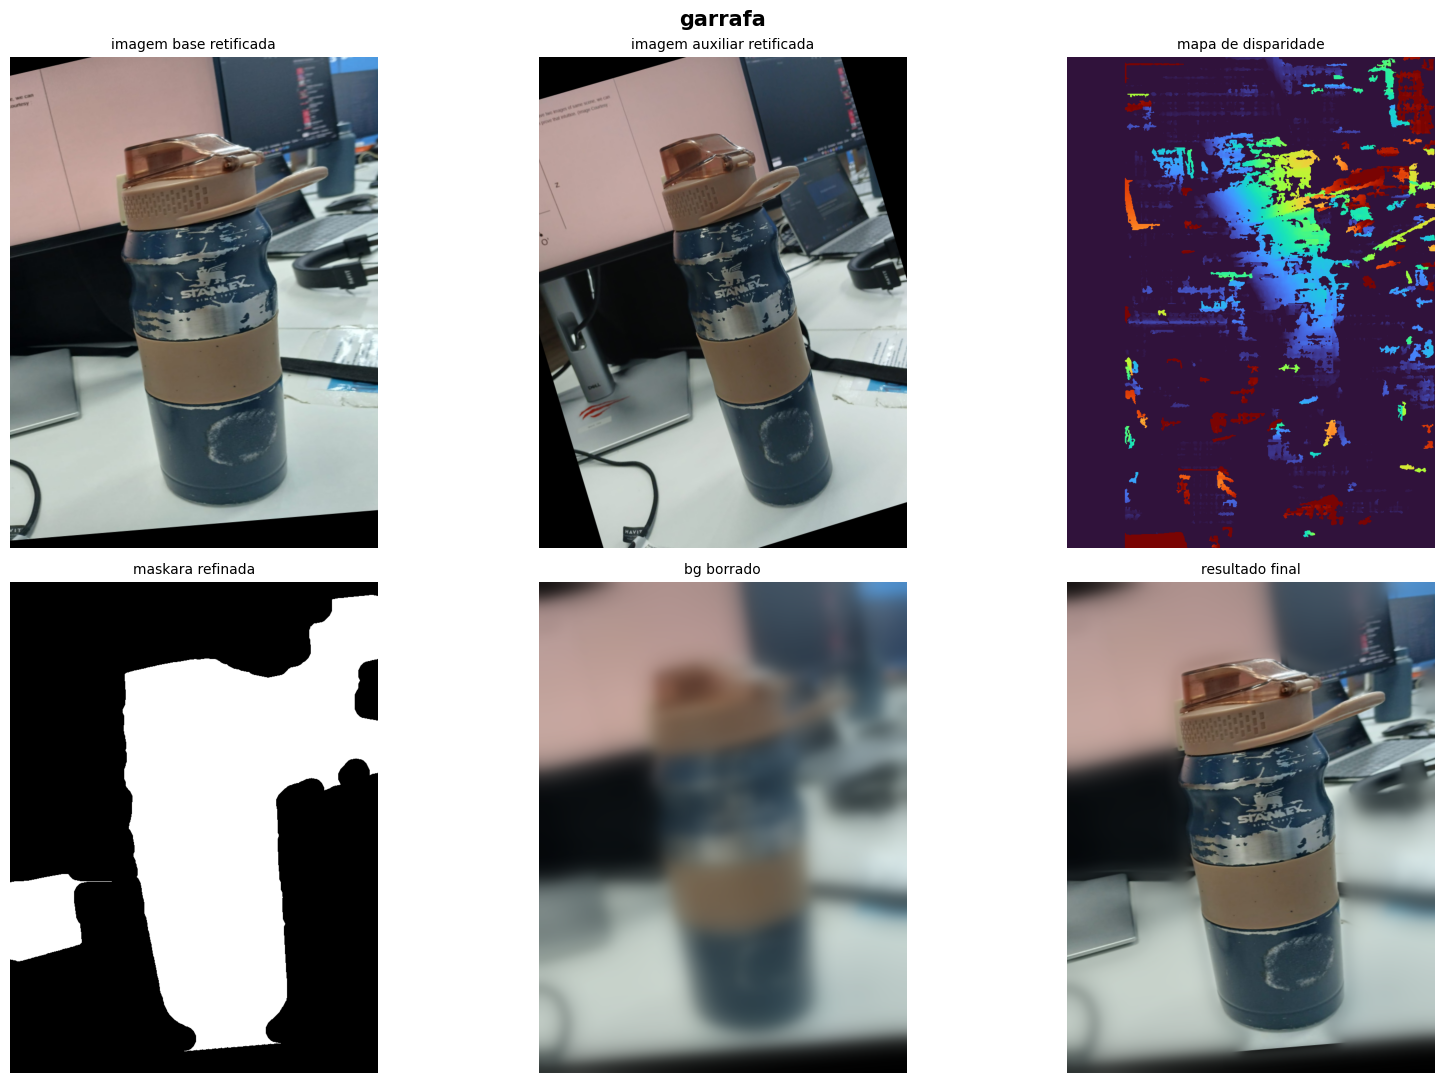

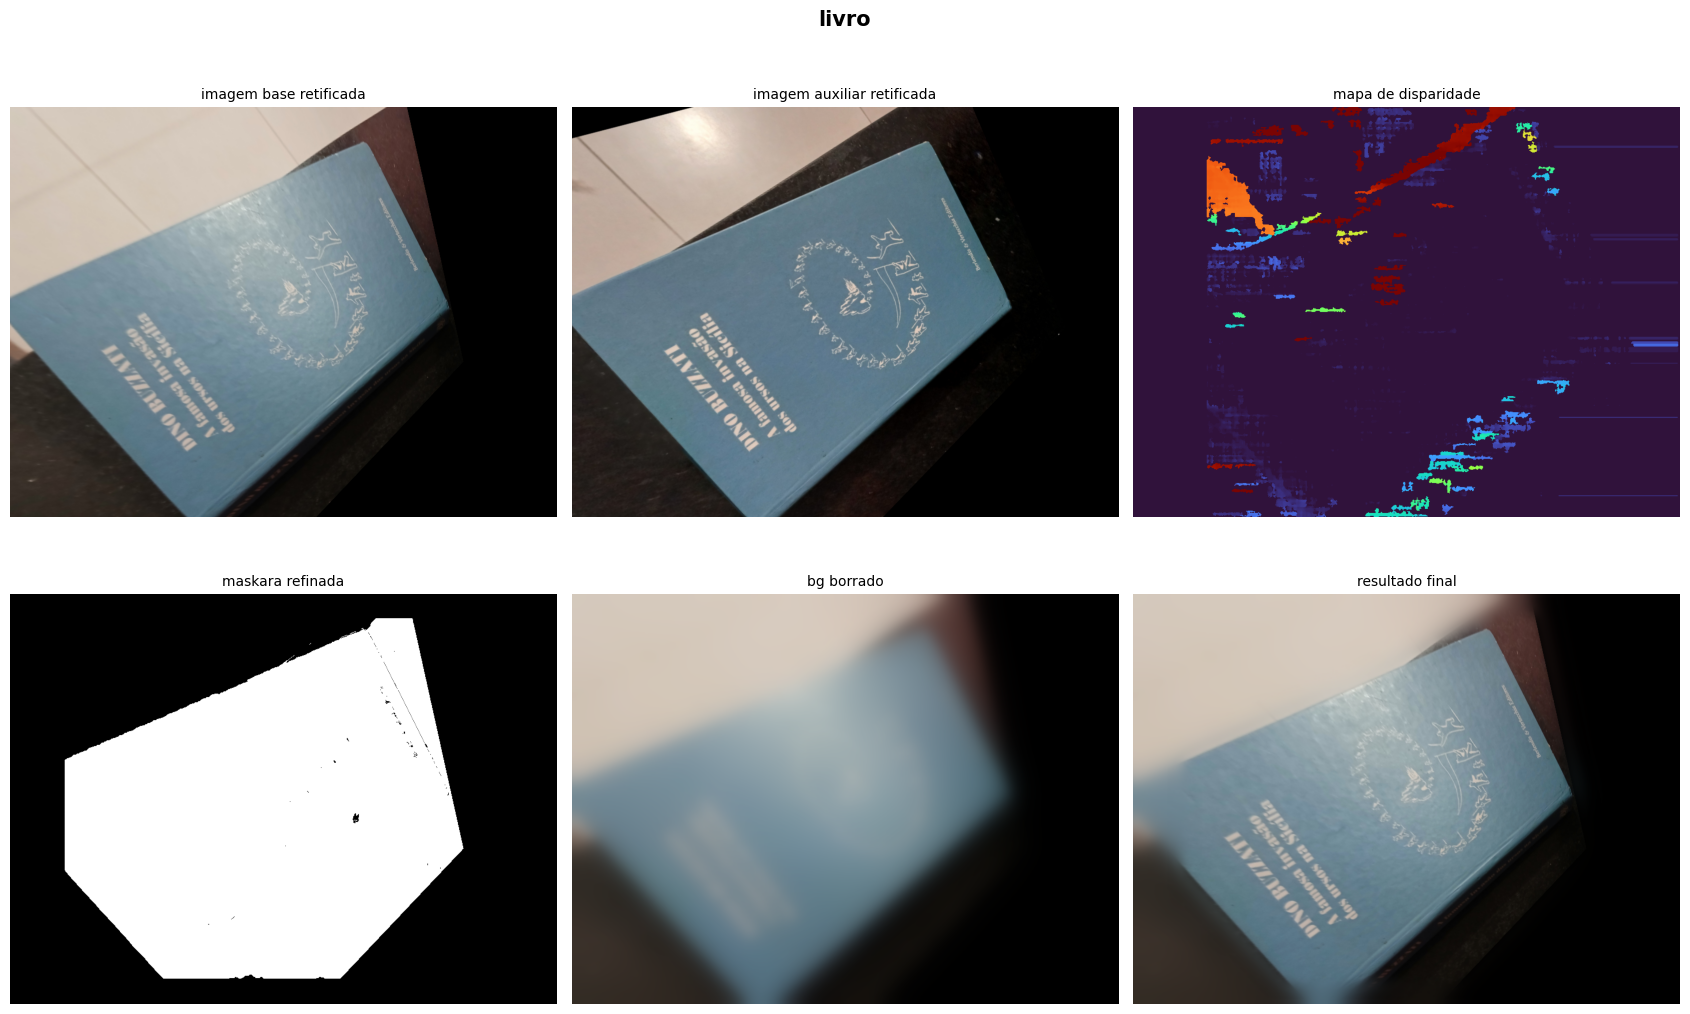

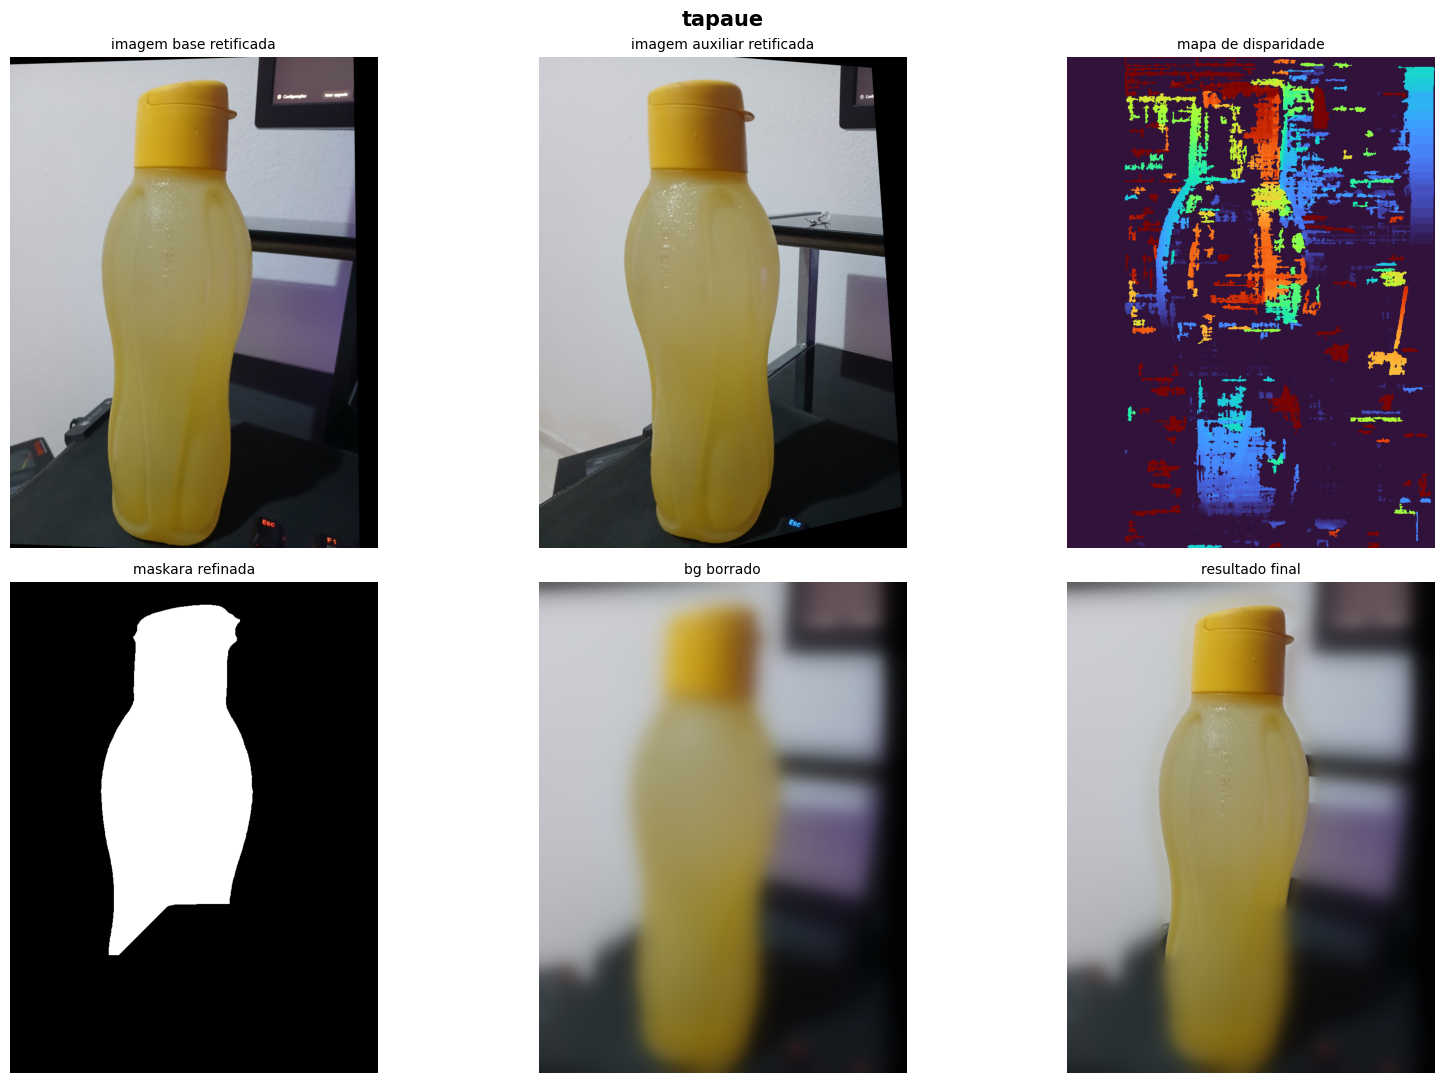

In [ ]:
from pathlib import Path
import cv2
import numpy as np
from matplotlib import pyplot as plt


BASE_DIR = Path('./')
OUT_DIR = BASE_DIR / "4-results"

PAIRS = [
    ("garrafa", "garrafa_esq.png", "garrafa_dir.png"),
    ("livro", "livro2.jpg", "livro3.jpg"),
    ("tapaue", "gar2.jpg", "gar3.jpg"),
]


def load_image(filename, max_side=950):
    path = BASE_DIR / filename
    img = cv2.imread(str(path))
    h, w = img.shape[:2]
    scale = min(1.0, max_side / max(h, w))

    if scale < 1.0:
        img = cv2.resize(
            img,
            (int(w * scale), int(h * scale)),
            interpolation=cv2.INTER_AREA
        )
    return img


def to_gray_equalized(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(
        clipLimit=2.2,
        tileGridSize=(8, 8)
    )

    return clahe.apply(gray)


def detect_matches(img_l, img_r):
    gray_l = to_gray_equalized(img_l)
    gray_r = to_gray_equalized(img_r)

    if hasattr(cv2, "SIFT_create"):
        detector = cv2.SIFT_create(nfeatures=6000)
        norm = cv2.NORM_L2
        ratio = 0.74
    else:
        detector = cv2.ORB_create(nfeatures=8000)
        norm = cv2.NORM_HAMMING
        ratio = 0.78

    kp_l, des_l = detector.detectAndCompute(gray_l, None)
    kp_r, des_r = detector.detectAndCompute(gray_r, None)
    matcher = cv2.BFMatcher(norm)
    raw_matches = matcher.knnMatch(des_l, des_r, k=2)

    good = []
    for pair in raw_matches:
        if len(pair) != 2:
            continue

        m, n = pair

        if m.distance < ratio * n.distance:
            good.append(m)
    pts_l = np.float32([kp_l[m.queryIdx].pt for m in good])
    pts_r = np.float32([kp_r[m.trainIdx].pt for m in good])

    return pts_l, pts_r, len(good)


def rectify_uncalibrated(img_l, img_r):
    h, w = img_l.shape[:2]

    pts_l, pts_r, total_matches = detect_matches(img_l, img_r)

    F, inlier_mask = cv2.findFundamentalMat(
        pts_l,
        pts_r,
        method=cv2.FM_RANSAC,
        ransacReprojThreshold=1.2,
        confidence=0.995,
        maxIters=5000
    )

    inlier_mask = inlier_mask.ravel().astype(bool)
    pts_l_in = pts_l[inlier_mask]
    pts_r_in = pts_r[inlier_mask]
    ok, H_l, H_r = cv2.stereoRectifyUncalibrated(
        pts_l_in,
        pts_r_in,
        F,
        imgSize=(w, h)
    )
    left_rect = cv2.warpPerspective(img_l, H_l, (w, h))
    right_rect = cv2.warpPerspective(img_r, H_r, (w, h))

    print(f"  matches bons: {total_matches} | inliers: {len(pts_l_in)}")

    return left_rect, right_rect


def compute_disparity(img_l, img_r):
    gray_l = to_gray_equalized(img_l)
    gray_r = to_gray_equalized(img_r)

    h, w = gray_l.shape

    block_size = 5
    min_disp = 0

    num_disp = max(16 * 6, int(w / 8))
    num_disp = ((num_disp // 16) + 1) * 16
    num_disp = min(num_disp, 16 * 12)

    stereo_l = cv2.StereoSGBM_create(
        minDisparity=min_disp,
        numDisparities=num_disp,
        blockSize=block_size,
        P1=8 * 3 * block_size ** 2,
        P2=32 * 3 * block_size ** 2,
        disp12MaxDiff=1,
        uniquenessRatio=7,
        speckleWindowSize=120,
        speckleRange=2,
        preFilterCap=63,
        mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY
    )

    stereo_r = cv2.StereoSGBM_create(
        minDisparity=-num_disp,
        numDisparities=num_disp,
        blockSize=block_size,
        P1=8 * 3 * block_size ** 2,
        P2=32 * 3 * block_size ** 2,
        disp12MaxDiff=1,
        uniquenessRatio=7,
        speckleWindowSize=120,
        speckleRange=2,
        preFilterCap=63,
        mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY
    )

    disp_l = stereo_l.compute(gray_l, gray_r).astype(np.float32) / 16.0
    disp_r = stereo_r.compute(gray_r, gray_l).astype(np.float32) / 16.0

    valid = disp_l > min_disp

    yy, xx = np.indices(disp_l.shape)
    xr = np.round(xx - disp_l).astype(np.int32)

    consistency = np.zeros_like(valid)
    inside = valid & (xr >= 0) & (xr < w)

    diff = np.zeros_like(disp_l)
    diff[inside] = np.abs(disp_l[inside] + disp_r[yy[inside], xr[inside]])
    consistency[inside] = diff[inside] < 2.0

    valid = valid & consistency

    disp_norm = np.zeros_like(disp_l, dtype=np.uint8)

    if np.count_nonzero(valid) > 0.01 * disp_l.size:
        values = disp_l[valid]
        lo, hi = np.percentile(values, [3, 97])
        disp_norm = np.clip((disp_l - lo) * 255.0 / max(hi - lo, 1e-6), 0, 255)
        disp_norm = disp_norm.astype(np.uint8)

    return disp_l, disp_norm, valid


def largest_components(mask, min_area_ratio=0.008, keep=3):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, 8)

    if num_labels <= 1:
        return mask

    areas = stats[1:, cv2.CC_STAT_AREA]
    order = np.argsort(areas)[::-1]

    min_area = min_area_ratio * mask.shape[0] * mask.shape[1]
    clean = np.zeros_like(mask)

    kept = 0
    for idx in order:
        label = idx + 1
        area = stats[label, cv2.CC_STAT_AREA]

        if area < min_area:
            continue

        clean[labels == label] = 255
        kept += 1

        if kept >= keep:
            break

    return clean


def disparity_mask(disparity, disp_norm, valid):
    mask = np.zeros(disparity.shape, dtype=np.uint8)

    if np.count_nonzero(valid) < 0.01 * disparity.size:
        return mask

    values = disparity[valid]

    threshold = np.percentile(values, 60)
    mask[(disparity >= threshold) & valid] = 255
    mask = cv2.medianBlur(mask, 7)
    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (27, 27))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_open, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_close, iterations=3)
    mask = largest_components(mask, min_area_ratio=0.01, keep=2)

    return mask


def fallback_grabcut_mask(img):
    h, w = img.shape[:2]

    rect = (
        int(w * 0.10),
        int(h * 0.06),
        int(w * 0.80),
        int(h * 0.88)
    )

    gc_mask = np.zeros((h, w), np.uint8)
    bg_model = np.zeros((1, 65), np.float64)
    fg_model = np.zeros((1, 65), np.float64)

    cv2.grabCut(
        img,
        gc_mask,
        rect,
        bg_model,
        fg_model,
        8,
        cv2.GC_INIT_WITH_RECT
    )

    mask = np.where(
        (gc_mask == cv2.GC_FGD) | (gc_mask == cv2.GC_PR_FGD),
        255,
        0
    ).astype(np.uint8)

    return mask


def refine_mask_with_grabcut(img, initial_mask):
    h, w = initial_mask.shape

    if np.count_nonzero(initial_mask) < 0.005 * initial_mask.size:
        return fallback_grabcut_mask(img)

    gc_mask = np.full((h, w), cv2.GC_PR_BGD, dtype=np.uint8)

    fg = initial_mask > 0
    bg = initial_mask == 0

    gc_mask[bg] = cv2.GC_PR_BGD
    gc_mask[fg] = cv2.GC_PR_FGD

    erode_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (17, 17))
    sure_fg = cv2.erode(initial_mask, erode_kernel, iterations=1) > 0

    border = np.zeros_like(initial_mask, dtype=np.uint8)
    border[:8, :] = 255
    border[-8:, :] = 255
    border[:, :8] = 255
    border[:, -8:] = 255

    sure_bg = border > 0

    gc_mask[sure_fg] = cv2.GC_FGD
    gc_mask[sure_bg] = cv2.GC_BGD

    bg_model = np.zeros((1, 65), np.float64)
    fg_model = np.zeros((1, 65), np.float64)

    cv2.grabCut(
        img,
        gc_mask,
        None,
        bg_model,
        fg_model,
        5,
        cv2.GC_INIT_WITH_MASK
    )

    refined = np.where(
        (gc_mask == cv2.GC_FGD) | (gc_mask == cv2.GC_PR_FGD),
        255,
        0
    ).astype(np.uint8)

    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    refined = cv2.morphologyEx(refined, cv2.MORPH_CLOSE, kernel_close, iterations=2)
    refined = largest_components(refined, min_area_ratio=0.01, keep=2)

    return refined


def make_soft_alpha(mask):
    mask = mask.astype(np.uint8)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    mask = cv2.dilate(mask, kernel, iterations=1)

    alpha = cv2.GaussianBlur(mask.astype(np.float32) / 255.0, (61, 61), 0)
    alpha = np.clip(alpha, 0.0, 1.0)

    return alpha[..., None]


def apply_portrait_effect(img, mask):
    blur_strong = cv2.GaussianBlur(img, (0, 0), sigmaX=24, sigmaY=24)
    blur_soft = cv2.GaussianBlur(img, (0, 0), sigmaX=10, sigmaY=10)

    background = cv2.addWeighted(blur_strong, 0.75, blur_soft, 0.25, 0)

    alpha = make_soft_alpha(mask)

    result = (
        alpha * img.astype(np.float32) +
        (1.0 - alpha) * background.astype(np.float32)
    )

    return np.clip(result, 0, 255).astype(np.uint8), background


def bgr_to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def show_and_save_grid(name, left, right, disp_color, mask, blurred_bg, result):
    OUT_DIR.mkdir(exist_ok=True)

    # cv2.imwrite(str(OUT_DIR / f"{name}_01_esquerda_retificada.png"), left)
    # cv2.imwrite(str(OUT_DIR / f"{name}_02_direita_retificada.png"), right)
    # cv2.imwrite(str(OUT_DIR / f"{name}_03_disparidade.png"), disp_color)
    # cv2.imwrite(str(OUT_DIR / f"{name}_04_mascara.png"), mask)
    # cv2.imwrite(str(OUT_DIR / f"{name}_05_fundo_borrado.png"), blurred_bg)
    # cv2.imwrite(str(OUT_DIR / f"{name}_06_modo_retrato.png"), result)

    fig, axes = plt.subplots(2, 3, figsize=(17, 11))
    fig.suptitle(
        f"{name}",
        fontsize=15,
        fontweight="bold"
    )

    items = [
        ("imagem base retificada", bgr_to_rgb(left), None),
        ("imagem auxiliar retificada", bgr_to_rgb(right), None),
        ("mapa de disparidade", bgr_to_rgb(disp_color), None),
        ("maskara refinada", mask, "gray"),
        ("bg borrado", bgr_to_rgb(blurred_bg), None),
        ("resultado final", bgr_to_rgb(result), None),
    ]

    for ax, (title, img, cmap) in zip(axes.flat, items):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=10)
        ax.axis("off")

    plt.tight_layout()

    grid_path = OUT_DIR / f"{name}_grade_completa.png"
    plt.savefig(str(grid_path), dpi=160, bbox_inches="tight")

    print(f"grade salva em: {grid_path}")


def process_pair(name, left_file, right_file):
    print(f"\nprocessando par {name}")

    img_l = load_image(left_file)
    img_r = load_image(right_file)

    if img_l.shape[:2] != img_r.shape[:2]:
        img_r = cv2.resize(
            img_r,
            (img_l.shape[1], img_l.shape[0]),
            interpolation=cv2.INTER_AREA
        )

    try:
        left_rect, right_rect = rectify_uncalibrated(img_l, img_r)
    except Exception as exc:
        print(f"retificacao falhou ({exc}); usando imagens originais")
        left_rect, right_rect = img_l, img_r

    disparity, disp_norm, valid = compute_disparity(left_rect, right_rect)

    disp_color = cv2.applyColorMap(disp_norm, cv2.COLORMAP_TURBO)

    initial_mask = disparity_mask(disparity, disp_norm, valid)
    refined_mask = refine_mask_with_grabcut(left_rect, initial_mask)

    result, blurred_bg = apply_portrait_effect(left_rect, refined_mask)

    show_and_save_grid(
        name,
        left_rect,
        right_rect,
        disp_color,
        refined_mask,
        blurred_bg,
        result
    )


def main():
    print("modo retrato usando mapa de disparidade")
    print("pares usados:")
    for name, left, right in PAIRS:
        print(f"  {name}: {left} + {right}")

    for name, left_file, right_file in PAIRS:
        try:
            process_pair(name, left_file, right_file)
        except Exception as exc:
            print(f"ERRO no par {name}: {exc}")

    print(f"resultados salvos em {OUT_DIR}")
    plt.show()


if __name__ == "__main__":
    main()